In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
#from lagranto import Tra
import math
#from GEOS5functions import *
import datetime
from scipy.ndimage import rotate
import colormaps as cmaps 
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
%run GEOS5functions.py
%matplotlib inline 

In [3]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

# Set the current storm index to ???
currentstorm = 74

# Reminder of what's in stormlist      
            stormlist[0][tccount] = tccount
            stormlist[1][tccount] = name
            stormlist[2][tccount] = name[0:3] # basin identifier
            stormlist[3][tccount] = dtstart
            stormlist[4][tccount] = dtend
            stormlist[5][tccount] = lat1
            stormlist[6][tccount] = lat2
            stormlist[7][tccount] = lon1
            stormlist[8][tccount] = lon2

In [4]:
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

timesel = slice(starttime ,endtime)
extended_timesel = slice(starttime - datetime.timedelta(days=5) ,endtime + datetime.timedelta(days=5))
degbuffer = 20
latsel = slice(lat1-degbuffer,lat2+degbuffer)
lonsel = slice(lon1-degbuffer,lon2+degbuffer)

In [5]:
timesel

slice(datetime.datetime(2005, 10, 9, 10, 0), datetime.datetime(2005, 10, 16, 20, 0), None)

In [6]:
extended_timesel

slice(datetime.datetime(2005, 10, 4, 10, 0), datetime.datetime(2005, 10, 21, 20, 0), None)

In [7]:
stormname = stormlist[1][currentstorm][0:9]
print(stormname)

npc05tc21


In [8]:
stormtraj = np.load('/home/modares/TC/trajectory/' + str(stormname)+'.npz')
minpres = stormtraj['minpres']
timee = stormtraj['time']
minplat = stormtraj['minplat']
minplon = stormtraj['minplon']

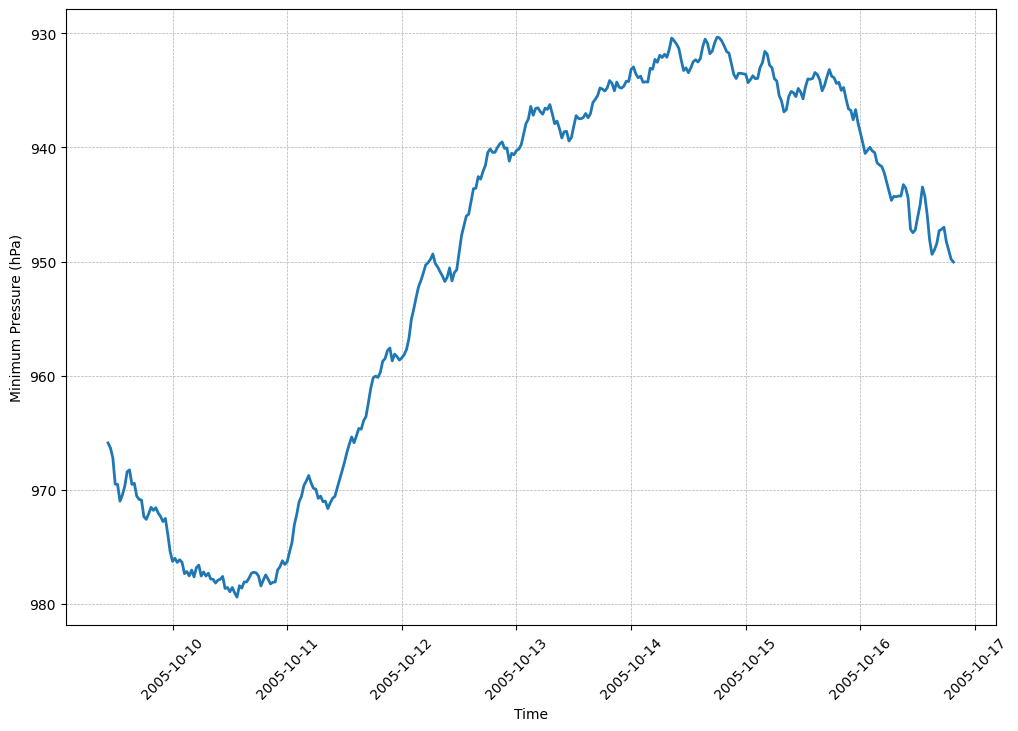

In [11]:
minpres = stormtraj['minpres']
timee = stormtraj['time']

fig, ax = plt.subplots(figsize=(12, 8))

plt.plot(timee, minpres/100,linewidth=2 )

plt.xlabel('Time')
plt.ylabel('Minimum Pressure (hPa)')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.invert_yaxis()
plt.xticks(rotation=45)

#plt.savefig('npc06tc01_intensity.png', bbox_inches='tight', transparent=True)


plt.show()

In [14]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['U', 'V', 'SO4', 'CLOUD', 'PL', 'DELP', 'H', 'TAUIR', 'SO2']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_3d_' + varvec[vind] + '_Nv'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'U':
        dsu = xr.open_dataset(url)  # Open dataset for 'U' (zonal wind component)
    if varvec[vind] == 'V':
        dsv = xr.open_dataset(url)  # Open dataset for 'V' (meridional wind component)
    if varvec[vind] == 'SO4':
        dsso4 = xr.open_dataset(url)  # Open dataset for 'DELP' (surface pressure and pressure thickness)
    if varvec[vind] == 'CLOUD':
        dscloud = xr.open_dataset(url)
    if varvec[vind] == 'PL':
        dspl = xr.open_dataset(url)
    if varvec[vind] == 'DELP':
        dsdelp = xr.open_dataset(url)
    if varvec[vind] == 'H':
        dsh = xr.open_dataset(url)
    if varvec[vind] == 'SO2':
        dsso2 = xr.open_dataset(url)

# Print a success message indicating that the datasets have been read successfully
print('success reading')


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-pack

success reading


In [15]:

dsdelp = dsdelp.sel(time= extended_timesel )
dsh = dsh.sel(time= extended_timesel )
dsso4 = dsso4.sel(time= extended_timesel )
dsso2 = dsso2.sel(time= extended_timesel )




In [16]:
timesel = timee

In [18]:
first_value = minplat[0]  
last_value = minplat[-1]  

# Create arrays of 48 elements with the first and last values
prefix_array = np.full(240, first_value)
suffix_array = np.full(240, last_value)

# Concatenate the arrays
extended_minplat = np.concatenate([prefix_array, minplat, suffix_array])
extended_minplat.size

835

In [19]:
first_value = minplon[0]  
last_value = minplon[-1]  

# Create arrays of 48 elements with the first and last values
prefix_array = np.full(240, first_value)
suffix_array = np.full(240, last_value)

# Concatenate the arrays
extended_minplon = np.concatenate([prefix_array, minplon, suffix_array])
extended_minplon.size

835

# SO4 Plot

In [20]:
dsso4

<xarray.Dataset> Size: 4TB
Dimensions:  (time: 835, lev: 72, lat: 2881, lon: 5760)
Coordinates:
  * time     (time) datetime64[ns] 7kB 2005-10-04T10:30:00 ... 2005-10-21T19:...
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * lat      (lat) float64 23kB -90.0 -89.94 -89.88 -89.81 ... 89.88 89.94 90.0
  * lon      (lon) float64 46kB -180.0 -179.9 -179.9 ... 179.8 179.9 179.9
Data variables:
    so4      (time, lev, lat, lon) float32 4TB ...
Attributes:
    title:                3d,30-Minute,Instantaneous,Model-Level,Full Resolut...
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Wed Apr 22 16:28:37 GMT 2026 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...

In [21]:
timee.size

355

In [22]:
minpres.argmin()

np.int64(255)

In [23]:
buffer = 30

In [24]:
arg = 20 #minpres.argmin()

In [25]:
leve= 39

In [26]:
minplat[arg]
minplon[arg]

np.float64(148.4375)

In [27]:
indices = np.where(timee == '2005-10-14T20:29:59.999997000')[0]
indices

array([], dtype=int64)

In [28]:
timee[arg]

np.datetime64('2005-10-09T20:29:59.999997000')

In [29]:

min_time = timee[arg]

bufferup = 8
bufferdise = 26

latsel = slice(minplat[arg] - bufferup, minplat[arg] + bufferup)
    
lonsel = slice(minplon[arg] - bufferdise -5, minplon[arg] + bufferdise  -5)

# Selecting datasets
so4mr = dsso4['so4'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
so2mr = dsso2['so2'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
uwind = dsu['u'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
vwind = dsv['v'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
pl = dspl['pl'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
delp = dsdelp['delp'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
#h_low = dsh['h'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve + 1)
#h_high = dsh['h'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve - 1)
h_mid = dsh['h'].sel(time=min_time, lat=latsel, lon=lonsel, lev=leve)
    
if np.mean(so4mr.lat.values) < 0:
        
    so4 = so4mr.sel(lat=slice(None, None, -1))
    uwind = uwind.sel(lat=slice(None, None, -1))
    vwind = vwind.sel(lat=slice(None, None, -1))


"\nmin_time = arg\n    \nlatsel = slice(extended_minplat[arg] - buffer, extended_minplat[arg] + buffer)\n    \nlonsel = slice(extended_minplon[arg] - buffer, extended_minplon[arg] + buffer)\n\n# Selecting datasets\nso4 = dsso4['so4'].sel( lat=latsel, lon=lonsel, lev=leve).isel(time = arg)\nuwind = dsu['u'].sel( lat=latsel, lon=lonsel, lev=leve).isel(time = arg)\nvwind = dsv['v'].sel( lat=latsel, lon=lonsel, lev=leve).isel(time = arg)\npl = dspl['pl'].sel( lat=latsel, lon=lonsel, lev=leve).isel(time = arg)\n"

In [30]:
min_time

np.datetime64('2005-10-09T20:29:59.999997000')

In [32]:
avgpress = int(pl.mean().item()/100)

avgpress

118

In [33]:
#so4 = (so4mr * delp * 1e+9) / (((h_high - h_low)/2) * 9.81) 

so4 = so4mr * (28.96/96.06) * 1e+6

so2 = so2mr * (28.96/64.066) * 1e+6

In [34]:
so4.mean()

<xarray.DataArray 'so4' ()> Size: 4B
array(5.6867208e-05, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2005-10-09T20:29:59.999997
    lev      float64 8B 39.0

In [35]:
so2.mean()

<xarray.DataArray 'so2' ()> Size: 4B
array(1.0609571e-05, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2005-10-09T20:29:59.999997
    lev      float64 8B 39.0

In [36]:
min_time

np.datetime64('2005-10-09T20:29:59.999997000')

# SO4

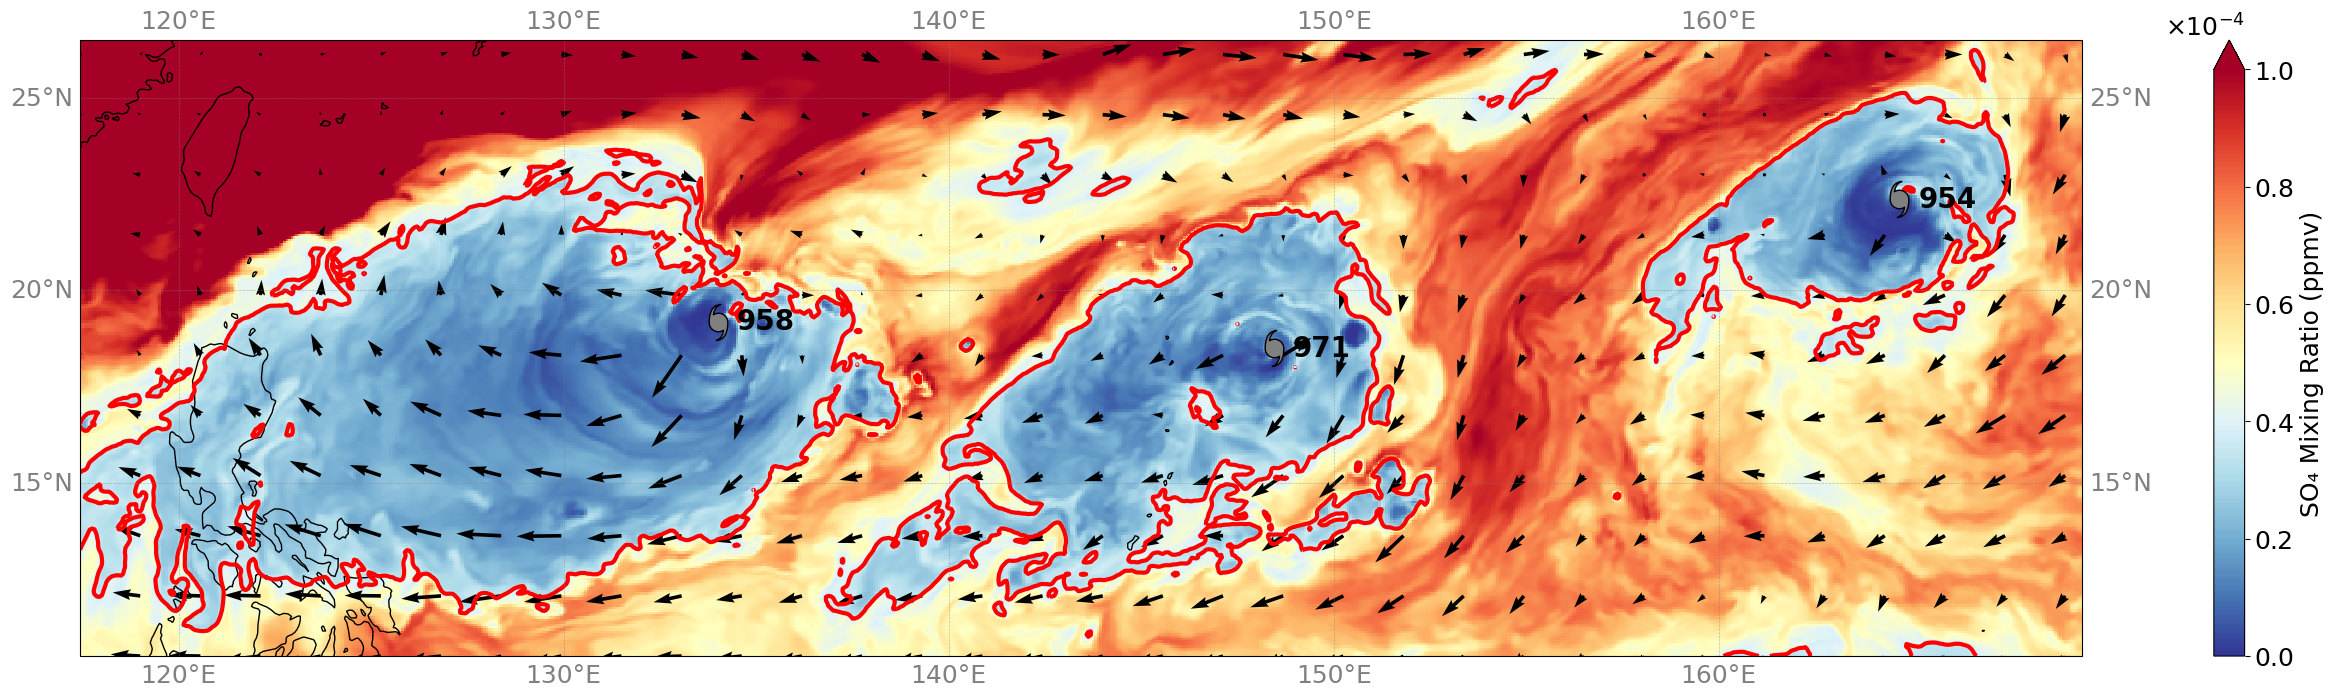

In [37]:
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.pyplot as plt
import tcmarkers
plt.style.use('tableau-colorblind10')

mpl.rcParams.update({'font.size': 18})  # Change 12 to your preferred base size

fig, ax = plt.subplots(figsize=(34, 8), subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Calculate wind speed
wind_speed = np.sqrt(uwind**2 + vwind**2)

# Prepare wind components
u_selected_np = uwind.values
v_selected_np = vwind.values
wind_speed_np = wind_speed.values

flux_min = 0
flux_max = 1 * 1e-4
contour = ax.pcolormesh(so4.lon, so4.lat, so4, cmap='RdYlBu_r', 
                        norm=mcolors.Normalize(vmin=flux_min, vmax=flux_max))

cbar1 = fig.colorbar(contour, ax=ax, label='SO₄ Mixing Ratio (ppmv)', extend='max')
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))
cbar1.ax.yaxis.set_major_formatter(formatter)

# --- Replace streamplot with quiver ---
# You may downsample for clarity (e.g., every 3rd arrow)
step = 25
ax.quiver(
    so4.lon.values[::step], 
    so4.lat.values[::step], 
    u_selected_np[::step, ::step], 
    v_selected_np[::step, ::step], 
    scale=1000,  # adjust scale to make arrows readable
    width=0.0018,
    color='black'
)

# Smooth the data for the contour
so4_smoothed = gaussian_filter(so4.values, sigma=0)
low_value_threshold = np.percentile(so4.values, 30)

# Add red contour
low_value_contour = ax.contour(so4.lon, so4.lat, so4_smoothed, 
                               levels=[low_value_threshold], 
                               colors='red', linewidths=3)

# Gridlines and axis formatting
crs0 = ccrs.PlateCarree()
gl = ax.gridlines(crs=crs0, draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

gl.ylocator = mticker.FixedLocator([ 10, 15, 20, 25])
gl.xlabel_style = {'size': 18, 'color': 'gray'}
gl.ylabel_style = {'size': 18, 'color': 'gray'}

#ax.set_xlabel('Longitude', fontsize=12)
#ax.set_ylabel('Latitude')

ax.set_ylim(minplat[arg] - bufferup, minplat[arg] + bufferup)
ax.set_xlim(minplon[arg] - bufferdise  -5, minplon[arg] + bufferdise  -5)

# Example: Place hurricane icon at a specific lat/lon
hurr_lons = [134,148.4375, 164.6875]
hurr_lats = [19.1875,18.5, 22.375]
hurr_names = ['958', '971','954']


# Plot storm center
for lon, lat, name in zip(hurr_lons, hurr_lats, hurr_names):
    # Plot the 'x' with color
    #ax.text(lon, lat, 'O', fontsize=25, color='black', ha='center', va='center', transform=ccrs.PlateCarree())
    marker_kwargs = {'markersize': 13, 'color':'grey', 'markeredgecolor':'black'}
    ax.plot(lon, lat, marker=tcmarkers.HU, **marker_kwargs)

    
    # Add name beside it (e.g., slightly east of the 'x')
    ax.text(lon + 0.5, lat , name, fontsize=20, color='black', ha='left', va='center', fontweight='bold', transform=ccrs.PlateCarree())


plt.savefig('SO4_' + f'{stormname}' + 'withquiver_' + f'{leve}' +
            '_width_' + str(buffer) + f'time_{arg}' + '.png',
            bbox_inches='tight', transparent=True)
plt.show()


In [38]:
low_value_threshold

np.float32(3.7506245e-05)

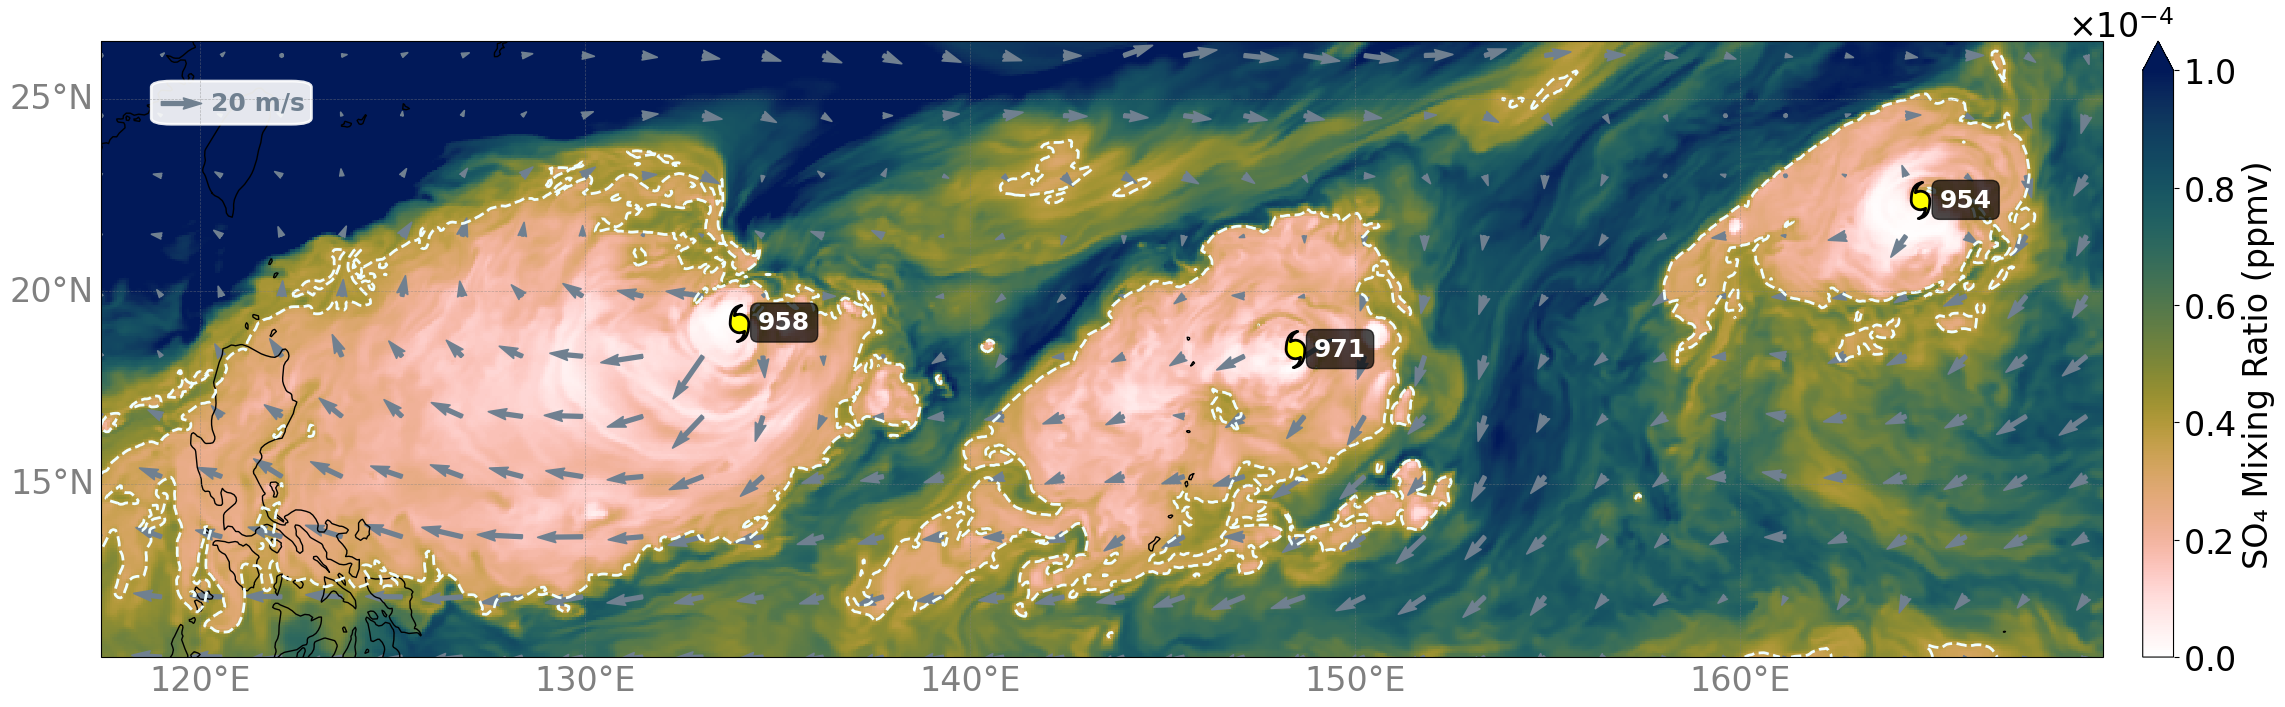

In [39]:
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import tcmarkers
from matplotlib.patches import FancyBboxPatch


plt.style.use('tableau-colorblind10')


mpl.rcParams.update({'font.size': 24})

fig, ax = plt.subplots(figsize=(34, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Calculate wind speed
wind_speed = np.sqrt(uwind**2 + vwind**2)
u_selected_np = uwind.values
v_selected_np = vwind.values
wind_speed_np = wind_speed.values

flux_min = 0
flux_max = 1 * 1e-4

# Use colorblind-friendly colormap
contour = ax.pcolormesh(so4.lon, so4.lat, so4, cmap=cmaps.batloww_r,  # Changed from 'RdYlBu_r'
                        norm=mcolors.Normalize(vmin=flux_min, vmax=flux_max))

cbar1 = fig.colorbar(contour, ax=ax, label='SO₄ Mixing Ratio (ppmv)', extend='max', pad=0.015)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))
cbar1.ax.yaxis.set_major_formatter(formatter)

# Quiver plot
step = 25
Q = ax.quiver(
    so4.lon.values[::step], 
    so4.lat.values[::step], 
    u_selected_np[::step, ::step], 
    v_selected_np[::step, ::step], 
    scale=1000,
    width=0.0018,
    color='slategrey',  # White arrows stand out better on viridis
    edgecolors='slategrey',  # Add edge for better visibility
    linewidths=1.2
)

# Add quiver key (scale reference)
qk = ax.quiverkey(Q, 0.05, 0.9,  # X, Y position (in axes coordinates, 0-1)
             20,  # Reference vector magnitude (e.g., 10 m/s)
             '20 m/s',  # Label
             labelpos='E',  # Label position: 'N', 'S', 'E', 'W'
             coordinates='axes',
             color='slategrey',
             labelcolor='slategrey',
             fontproperties={'size': 18, 'weight': 'bold'})

# Add a box around both the arrow and text
# Position and size may need adjustment based on your figure
box = FancyBboxPatch((0.035, 0.875),  # (x, y) lower-left corner in axes coords
                     0.06, 0.05,     # width, height
                     boxstyle="round,pad=0.01",
                     edgecolor='w',
                     facecolor='w',
                     alpha=0.9,
                     linewidth=2,
                     transform=ax.transAxes,
                     zorder=2)  # Make sure box is behind quiver key
ax.add_patch(box)

# Adjust quiver key zorder to appear on top of box
qk.set_zorder(3)


# Smooth the data for the contour
so4_smoothed = gaussian_filter(so4.values, sigma=0)
low_value_threshold = np.percentile(so4.values, 30)

# Add high-contrast contour with distinctive line style
low_value_contour = ax.contour(so4.lon, so4.lat, so4_smoothed, 
                               levels=[low_value_threshold], 
                               colors='azure',  # Changed from red
                               linewidths=2.0,  # Thicker
                               linestyles='--')  # Dashed for extra distinction

# Gridlines and axis formatting
# Gridlines and axis formatting
crs0 = ccrs.PlateCarree()
gl = ax.gridlines(
    crs=crs0,
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Turn off top and right labels
gl.top_labels = False     # no x-labels on top
gl.right_labels = False   # no y-labels on right

# Keep bottom and left labels (default is True)
gl.bottom_labels = True
gl.left_labels = True

gl.ylocator = mticker.FixedLocator([10, 15, 20, 25])
gl.xlabel_style = {'size': 24, 'color': 'gray'}
gl.ylabel_style = {'size': 24, 'color': 'gray'}

ax.set_ylim(minplat[arg] - bufferup, minplat[arg] + bufferup)
ax.set_xlim(minplon[arg] - bufferdise - 5, minplon[arg] + bufferdise - 5)

# Hurricane markers
hurr_lons = [134, 148.4375, 164.6875]
hurr_lats = [19.1875, 18.5, 22.375]
hurr_names = ['958', '971', '954']

for lon, lat, name in zip(hurr_lons, hurr_lats, hurr_names):
    marker_kwargs = {'markersize': 13, 'color': 'yellow', 'markeredgecolor': 'black', 'markeredgewidth': 2}
    ax.plot(lon, lat, marker=tcmarkers.HU, **marker_kwargs)
    ax.text(lon + 0.5, lat, name, fontsize=18, color='white', ha='left', va='center', 
            fontweight='bold', transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))  # Add background for readability

plt.savefig('SO4_' + f'{stormname}' + 'withquiver_' + f'{leve}' +
            '_width_' + str(buffer) + f'time_{arg}' + '_final.png',
            bbox_inches='tight', transparent=True, dpi=300)
plt.show()